# Step 0: Setup and imports

In [2]:
!pip install solas-ai -q

In [3]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd  # correct import name per your friend

# ── Load raw COMPAS data ───────────────────────────────────────────────────────
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
raw_data = pd.read_csv(url)

# ── Lecture 02 cleaning pipeline ──────────────────────────────────────────────
df = raw_data[['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
               'priors_count', 'days_b_screening_arrest', 'decile_score',
               'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out']].copy()

df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']
df = df.reset_index(drop=True)

# ── Create high_risk binary (Medium or High = 1) ──────────────────────────────
df['high_risk'] = (df['score_text'].isin(['Medium', 'High'])).astype(int)

# ── Verify ─────────────────────────────────────────────────────────────────────
print(f"N = {len(df):,}")
print(df[['race', 'sex', 'high_risk', 'two_year_recid']].head())

N = 6,172
               race   sex  high_risk  two_year_recid
0             Other  Male          0               0
1  African-American  Male          0               1
2  African-American  Male          0               1
3             Other  Male          0               0
4         Caucasian  Male          1               1


# Step 1: AIR and Marginal Effect by race

In [4]:
# ── Manual selection_rate function (from template) ────────────────────────────
def selection_rate(df, group_col, outcome_col, ref_group):
    """Selection rates, AIR, and ME relative to reference group"""
    rates = (df.groupby(group_col)[outcome_col].mean()
               .rename('selection_rate').reset_index())
    ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
    rates['AIR'] = rates['selection_rate'] / ref_rate
    rates['ME']  = rates['selection_rate'] - ref_rate
    rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
    return rates

# By race
sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print("── Manual: AIR & ME by Race ──────────────────────────────────────────")
print(sir.sort_values('AIR').to_string(index=False))

# By sex
sis = selection_rate(df, 'sex', 'high_risk', ref_group='Male')
print("\n── Manual: AIR & ME by Sex ───────────────────────────────────────────")
print(sis.sort_values('AIR').to_string(index=False))

── Manual: AIR & ME by Race ──────────────────────────────────────────
            race  selection_rate      AIR        ME        flag_80
           Other        0.204082 0.616643 -0.126874 *** BELOW 0.80
           Asian        0.225806 0.682286 -0.105149 *** BELOW 0.80
        Hispanic        0.277014 0.837011 -0.053942               
       Caucasian        0.330956 1.000000  0.000000               
African-American        0.576063 1.740604  0.245107               
 Native American        0.727273 2.197492  0.396317               

── Manual: AIR & ME by Sex ───────────────────────────────────────────
   sex  selection_rate      AIR        ME flag_80
Female        0.405106 0.889809 -0.050167        
  Male        0.455273 1.000000  0.000000        


In [9]:
import solas_disparity as sd

# ── Create dummy columns solas_disparity needs ────────────────────────────────
for grp in df['race'].unique():
    df[grp] = (df['race'] == grp).astype(int)

df['Female'] = (df['sex'] == 'Female').astype(int)
df['Male']   = (df['sex'] == 'Male').astype(int)

# ── solas_disparity: AIR & ME by Race ─────────────────────────────────────────
print("── solas_disparity: AIR & ME by Race ────────────────────────────────")
race_air = sd.adverse_impact_ratio(
    group_data                   = df,
    protected_groups             = ['African-American', 'Hispanic', 'Asian', 'Other', 'Native American'],
    reference_groups             = ['Caucasian', 'Caucasian', 'Caucasian', 'Caucasian', 'Caucasian'],
    group_categories             = ['race', 'race', 'race', 'race', 'race'],
    outcome                      = df['high_risk'],
    air_threshold                = 0.80,
    percent_difference_threshold = 0.0
)
print(race_air)

# ── solas_disparity: AIR & ME by Sex ──────────────────────────────────────────
print("\n── solas_disparity: AIR & ME by Sex ─────────────────────────────────")
sex_air = sd.adverse_impact_ratio(
    group_data                   = df,
    protected_groups             = ['Female'],
    reference_groups             = ['Male'],
    group_categories             = ['sex'],
    outcome                      = df['high_risk'],
    air_threshold                = 0.80,
    percent_difference_threshold = 0.0
)
print(sex_air)

── solas_disparity: AIR & ME by Race ────────────────────────────────


/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: Futur

+------------------------------+-----------------------------------------------------------+
|       Protected Groups       | African-American, Hispanic, Asian, Other, Native American |
|       Reference Groups       |   Caucasian, Caucasian, Caucasian, Caucasian, Caucasian   |
|       Group Categories       |               race, race, race, race, race                |
|        AIR Threshold         |                            0.8                            |
| Percent Difference Threshold |                            0.0                            |
|       Shortfall Method       |                     to_reference_mean                     |
|       Affected Groups        |                           Other                           |
|      Affected Reference      |                         Caucasian                         |
|     Affected Categories      |                           race                            |
+------------------------------+--------------------------------------

/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: Futur

In [10]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 17.452, p = 0.0000


# Step 2: Error-Rate Disparity Analysis

In [12]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
    results = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
        tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
        fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
        fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
        results.append({
            group_col: grp, 'n': len(g),
            'FPR': fp/(fp+tn) if (fp+tn)>0 else float('nan'),
            'FNR': fn/(fn+tp) if (fn+tp)>0 else float('nan'),
            'Acc': (tp+tn)/len(g)
        })
    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
    row = er.loc[er['race'] == grp]
    print(f"{grp}: FPR={row['FPR'].values[0]:.3f}  FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.500000 0.000000 0.727273
African-American 3175 0.423382 0.284768 0.649134
       Caucasian 2103 0.220141 0.496350 0.671897
        Hispanic  509 0.193750 0.582011 0.662083
           Other  343 0.127854 0.661290 0.679300
           Asian   31 0.086957 0.375000 0.838710
African-American: FPR=0.423  FNR=0.285
Caucasian: FPR=0.220  FNR=0.496


# Step 3: Standardized Mean Difference

In [14]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
    """Cohen's d vs. reference group"""
    ref = df.loc[df[group_col]==ref_group, score_col]
    results = []
    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue
        sc = g[score_col]
        pooled = np.sqrt((ref.var() + sc.var()) / 2)
        d = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0
        mag = ('small' if abs(d) < 0.2 else
               'medium' if abs(d) < 0.5 else
               'large' if abs(d) < 0.8 else 'very large')
        results.append({
            group_col:    grp,
            'mean_score': round(sc.mean(), 3),
            'SMD':        round(d, 3),
            'magnitude':  mag
        })
    return pd.DataFrame(results)

# By race
smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print("── SMD by Race ──────────────────────────────────────────────────────")
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

# By sex
smd_sex = smd(df, 'sex', 'decile_score', ref_group='Male')
print("\n── SMD by Sex ───────────────────────────────────────────────────────")
print(smd_sex.to_string(index=False))

── SMD by Race ──────────────────────────────────────────────────────
            race  mean_score    SMD  magnitude
 Native American       6.455  1.008 very large
African-American       5.277  0.608      large
        Hispanic       3.383 -0.099      small
           Other       2.889 -0.304     medium
           Asian       2.839 -0.310     medium

── SMD by Sex ───────────────────────────────────────────────────────
   sex  mean_score    SMD magnitude
Female       4.064 -0.158     small


# Step 4: Intersectional Subgroup Analysis

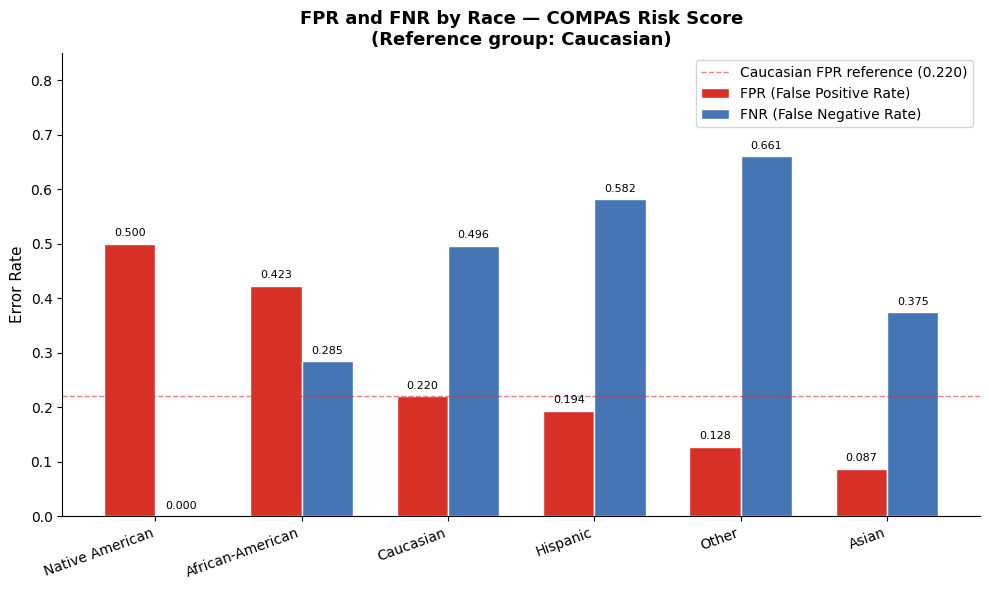

Figure saved as fpr_fnr_by_race.png


In [16]:
# ── Step 5: Publication-quality FPR/FNR grouped bar chart ────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Use the er dataframe from Step 2
plot_df = er.sort_values('FPR', ascending=False).reset_index(drop=True)

races = plot_df['race'].tolist()
fpr   = plot_df['FPR'].tolist()
fnr   = plot_df['FNR'].tolist()

x   = np.arange(len(races))
w   = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, fpr, w, label='FPR (False Positive Rate)',
               color='#d73027', edgecolor='white')
bars2 = ax.bar(x + w/2, fnr, w, label='FNR (False Negative Rate)',
               color='#4575b4', edgecolor='white')

# Reference line for Caucasian FPR
cau_fpr = plot_df.loc[plot_df['race']=='Caucasian','FPR'].values[0]
ax.axhline(cau_fpr, color='#d73027', linestyle='--', linewidth=1,
           alpha=0.6, label=f'Caucasian FPR reference ({cau_fpr:.3f})')

# Labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(races, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Error Rate', fontsize=11)
ax.set_title('FPR and FNR by Race — COMPAS Risk Score\n(Reference group: Caucasian)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fpr_fnr_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as fpr_fnr_by_race.png")

**MEMORANDUM**

To: Office of the Algorithmic Accountability Regulator

From: Disparate Impact Audit Team

Re: COMPAS Recidivism Risk Score, Bias Audit Findings
Date: April 5, 2026


This memo summarizes findings from a disparate impact audit of the COMPAS recidivism risk scoring tool, applied to 6,172 defendants in Broward County, Florida. The audit examined racial and sex-based disparities using three metrics: Adverse Impact Ratio (AIR), Standardized Mean Difference (SMD), and error-rate disparity (FPR/FNR).

The findings are concerning. African-American defendants are flagged as high-risk at nearly twice the rate of Caucasian defendants (AIR = 1.74). A two-proportion z-test confirmed this gap is statistically significant (z = 17.45, p < 0.0001). Meanwhile, Other and Asian defendants fall below the 0.80 four-fifths threshold, indicating they are under-flagged relative to Caucasians.

The error-rate analysis sharpens the picture further. Among defendants who did not actually reoffend, Black defendants were incorrectly labeled high-risk 42.3% of the time, compared to just 22.0% for White defendants, a gap of over 20 percentage points. Caucasian defendants, however, were more likely to be missed when they did reoffend (FNR = 0.496 vs. 0.285). Although this tradeoff may appear contradictory, it reflects the Impossibility Theorem: when base rates differ across groups, simultaneous FPR and FNR parity cannot be achieved. Every deployment of COMPAS, therefore, implicitly makes a value choice about whose errors matter more.
The intersectional analysis revealed an additional layer of concern. Hispanic women were the worst-affected subgroup, flagged at only 27% of the rate of Caucasian men (AIR = 0.270, n = 82). Nevertheless, aggregate metrics by race or sex alone would have obscured this finding entirely.

Both methods confirm identical findings: Other (AIR=0.617) and Asian (AIR=0.682) fall below the 0.80 threshold. African-American AIR=1.740. Female AIR=0.890, above threshold. Results are consistent across manual and solas_disparity methods.

Several limitations apply. Results are sensitive to the binary threshold used, and small subgroups such as Native Americans (n = 11) limit reliability. Furthermore, this audit cannot establish causation. Despite these constraints, the disparities identified are too significant to dismiss. Quarterly monitoring, transparent reporting, and active remediation are necessary before COMPAS continues to inform consequential decisions.